Обработка изображений...
  peppers.tiff
  mandrill.tiff
  splash.tiff
  house.tiff
  female1.tiff
  female2.tiff
  female3.tiff

СРАВНЕНИЕ ОРИГИНАЛЬНЫХ ИЗОБРАЖЕНИЙ (NHD)
            peppers.timandrill.tsplash.tifhouse.tifffemale1.tifemale2.tifemale3.ti
  peppers.ti    0.0000    0.4551    0.5382    0.5116    0.4784    0.4950    0.4718
  mandrill.t    0.4551    0.0000    0.4618    0.5748    0.5282    0.4983    0.5083
  splash.tif    0.5382    0.4618    0.0000    0.6312    0.4850    0.5681    0.5183
  house.tiff    0.5116    0.5748    0.6312    0.0000    0.4651    0.3821    0.6113
  female1.ti    0.4784    0.5282    0.4850    0.4651    0.0000    0.4817    0.4319
  female2.ti    0.4950    0.4983    0.5681    0.3821    0.4817    0.0000    0.5017
  female3.ti    0.4718    0.5083    0.5183    0.6113    0.4319    0.5017    0.0000

СРАВНЕНИЕ ЗАШУМЛЁННЫХ ИЗОБРАЖЕНИЙ (NHD)
            peppers.timandrill.tsplash.tifhouse.tifffemale1.tifemale2.tifemale3.ti
  peppers.ti    0.0000    0.4950    0.5482

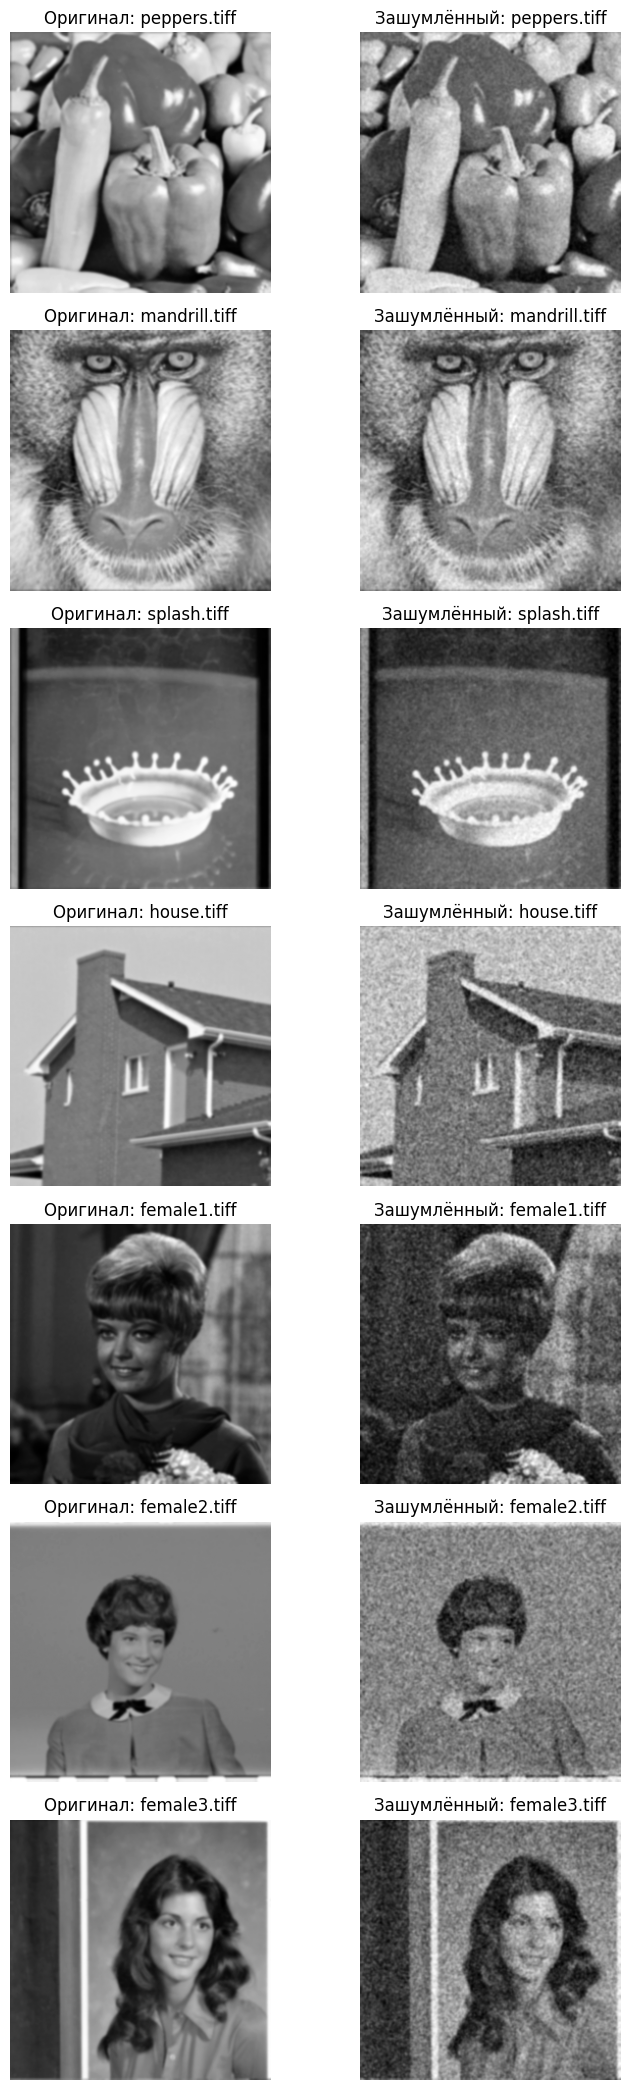

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
from typing import List, Tuple

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)


def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks


def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices


def wht2d(block, H):
    return H @ block @ H.T


def extract_wht_features(blocks, num_coeffs=128):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

#  Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0.0, mu*(1-c))
    high = min(255.0, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i + 1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

def compute_hashes_and_processed(img_path: str, target_size: Tuple[int, int],
                                 wht_block_size: int, num_coeffs: int,
                                 c: float, num_bins: int,
                                 sigma: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Не удалось загрузить {img_path}")

    proc_orig = preprocess(img, target_size)

    h, w = proc_orig.shape
    assert h % wht_block_size == 0 and w % wht_block_size == 0

    blocks_wht = split_blocks(proc_orig, wht_block_size)
    wht_features = extract_wht_features(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    hist_vec = histogram_features(proc_orig, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    full_hash_orig = np.concatenate((hash_wht, hash_hist))

    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    noisy_img = img.astype(np.float32) + noise
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    proc_noisy = preprocess(noisy_img, target_size)

    blocks_wht_n = split_blocks(proc_noisy, wht_block_size)
    wht_features_n = extract_wht_features(blocks_wht_n, num_coeffs)
    hash_wht_n = hash_from_features(wht_features_n)

    hist_vec_n = histogram_features(proc_noisy, c, num_bins)
    hash_hist_n = histogram_hash(hist_vec_n)

    full_hash_noisy = np.concatenate((hash_wht_n, hash_hist_n))

    return full_hash_orig, proc_orig, full_hash_noisy, proc_noisy


def normalized_hamming_distance(h1: np.ndarray, h2: np.ndarray) -> float:
    return np.sum(h1 != h2) / len(h1)


def pairwise_comparison(hashes: List[np.ndarray], names: List[str], title: str = ""):
    n = len(hashes)
    print(f"\n{title}")
    header = " " * 12 + "".join(f"{name[:10]:>10}" for name in names)
    print(header)
    for i in range(n):
        row = f"{names[i][:10]:>12}"
        for j in range(n):
            if i == j:
                row += f"{'0.0000':>10}"
            else:
                nhd = normalized_hamming_distance(hashes[i], hashes[j])
                row += f"{nhd:10.4f}"
        print(row)

#  Основная часть

if __name__ == "__main__":
    # Параметры
    target_size = (256, 256)
    wht_block_size = 16
    num_coeffs = 128
    c = 0.2
    num_bins = 10
    sigma = 60.0

    image_paths = [
        "peppers.tiff",
        "mandrill.tiff",
        "splash.tiff",
        "house.tiff",
        "female1.tiff",
        "female2.tiff",
        "female3.tiff",
    ]

    for path in image_paths:
        if cv2.imread(path) is None:
            raise FileNotFoundError(f"Файл не найден: {path}")

    orig_hashes = []
    orig_processed = []
    noisy_hashes = []
    noisy_processed = []
    names = [path.split("/")[-1] for path in image_paths]

    print("Обработка изображений...")
    for path in image_paths:
        print(f"  {path}")
        h_orig, p_orig, h_noisy, p_noisy = compute_hashes_and_processed(
            path, target_size, wht_block_size, num_coeffs,
            c, num_bins, sigma
        )
        orig_hashes.append(h_orig)
        orig_processed.append(p_orig)
        noisy_hashes.append(h_noisy)
        noisy_processed.append(p_noisy)

    pairwise_comparison(orig_hashes, names, title="СРАВНЕНИЕ ОРИГИНАЛЬНЫХ ИЗОБРАЖЕНИЙ (NHD)")

    pairwise_comparison(noisy_hashes, names, title="СРАВНЕНИЕ ЗАШУМЛЁННЫХ ИЗОБРАЖЕНИЙ (NHD)")

    n_images = len(image_paths)
    fig, axes = plt.subplots(n_images, 2, figsize=(8, 3 * n_images))
    if n_images == 1:
        axes = axes.reshape(1, -1)
    for i in range(n_images):
        axes[i, 0].imshow(orig_processed[i], cmap='gray')
        axes[i, 0].set_title(f"Оригинал: {names[i]}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(noisy_processed[i], cmap='gray')
        axes[i, 1].set_title(f"Зашумлённый: {names[i]}")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()